In [3]:
import pandas as pd
import numpy as np

data = {
    'age': [25, 30, np.nan, 40, 45],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'income': [50000, 60000, 70000, np.nan, 90000]
}
data_df = pd.DataFrame(data)

In [4]:
data_df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,Los Angeles,60000.0
2,NaN,Male,Chicago,70000.0
3,40.0,Female,Houston,NaN
4,45.0,Male,Phoenix,90000.0


In [5]:
print(data_df.isnull().sum())


age       1
gender    0
city      0
income    1
dtype: int64


In [7]:
data_df.describe()

,age,income
count,4.000000,4.000000
mean,35.000000,67500.000000
std,9.128709,17078.251277
min,25.000000,50000.000000
25%,28.750000,57500.000000
50%,35.000000,65000.000000
75%,41.250000,75000.000000
max,45.000000,90000.000000


In [11]:
data_df['age']

0    25.0
1    30.0
2     NaN
3    40.0
4    45.0
Name: age, dtype: float64

In [13]:
data_df['age'].fillna(data_df['age'].mean(), inplace=True)
data_df['age']

0    25.0
1    30.0
2    35.0
3    40.0
4    45.0
Name: age, dtype: float64

In [14]:
data_df['income'].fillna(data_df['income'].mean(), inplace=True)
data_df['income']

0    50000.0
1    60000.0
2    70000.0
3    67500.0
4    90000.0
Name: income, dtype: float64

In [20]:
data_df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,Los Angeles,60000.0
2,35.0,Male,Chicago,70000.0
3,40.0,Female,Houston,67500.0
4,45.0,Male,Phoenix,90000.0


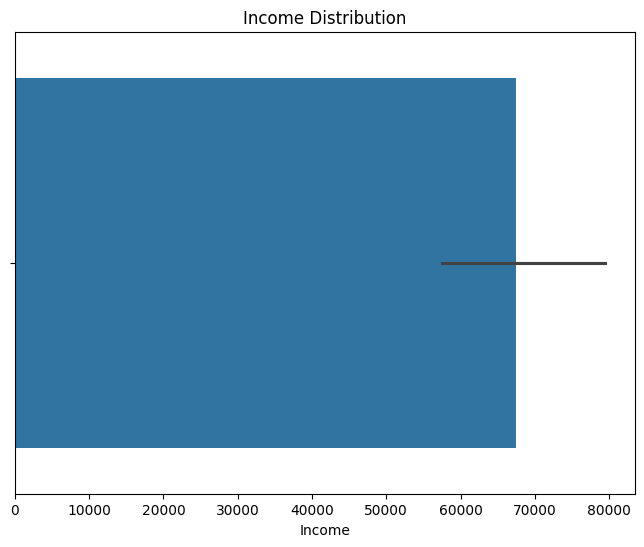

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=data_df['income'])
plt.title('Income Distribution')
plt.xlabel('Income')
plt.show()

In [23]:
data_withoutlier = {'income': [50000, 60000, 70000, 80000, 100000]}
data_outlier = pd.DataFrame(data_withoutlier)

mean_income = data_outlier['income'].mean()
std_income = data_outlier['income'].std()
median_income = data_outlier['income'].median()

data_outlier['income_mean'] = data_outlier['income'].fillna(mean_income)
data_outlier['income_median'] = data_outlier['income'].fillna(median_income)    

data_outlier

,income,income_mean,income_median
0,50000,50000,50000
1,60000,60000,60000
2,70000,70000,70000
3,80000,80000,80000
4,100000,100000,100000


In [24]:
data_df.head()

,age,gender,city,income
0,25.0,Male,New York,50000.0
1,30.0,Female,Los Angeles,60000.0
2,35.0,Male,Chicago,70000.0
3,40.0,Female,Houston,67500.0
4,45.0,Male,Phoenix,90000.0


In [25]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     5 non-null      float64
 1   gender  5 non-null      object 
 2   city    5 non-null      object 
 3   income  5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 292.0+ bytes


In [26]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data_df['city_encoded'] = label_encoder.fit_transform(data_df['city'])
data_df.head()

,age,gender,city,income,city_encoded
0,25.0,Male,New York,50000.0,3
1,30.0,Female,Los Angeles,60000.0,2
2,35.0,Male,Chicago,70000.0,0
3,40.0,Female,Houston,67500.0,1
4,45.0,Male,Phoenix,90000.0,4


In [28]:
data_df['gender_encoded'] = label_encoder.fit_transform(data_df['gender'])
data_df.head()

,age,gender,city,income,city_encoded,gender_encoded
0,25.0,Male,New York,50000.0,3,1
1,30.0,Female,Los Angeles,60000.0,2,0
2,35.0,Male,Chicago,70000.0,0,1
3,40.0,Female,Houston,67500.0,1,0
4,45.0,Male,Phoenix,90000.0,4,1


In [31]:
data_df.drop(['city', 'gender'], axis=1, inplace=True)
data_df.head()

,age,income,city_encoded,gender_encoded
0,25.0,50000.0,3,1
1,30.0,60000.0,2,0
2,35.0,70000.0,0,1
3,40.0,67500.0,1,0
4,45.0,90000.0,4,1


In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_df['age'] = scaler.fit_transform(data_df[['age']])
data_df['income'] = scaler.fit_transform(data_df[['income']])
data_df.head()

,age,income,city_encoded,gender_encoded
0,0.00,0.0000,3,1
1,0.25,0.2500,2,0
2,0.50,0.5000,0,1
3,0.75,0.4375,1,0
4,1.00,1.0000,4,1


In [34]:
from sklearn.model_selection import train_test_split
X = data_df.drop('income', axis=1)
y = data_df['income']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
print(X)

    age  city_encoded  gender_encoded
0  0.00             3               1
1  0.25             2               0
2  0.50             0               1
3  0.75             1               0
4  1.00             4               1


In [36]:
print(y)

0    0.0000
1    0.2500
2    0.5000
3    0.4375
4    1.0000
Name: income, dtype: float64


In [37]:
print(Xtrain)
print(ytrain)
print(Xtest)
print(ytest)

    age  city_encoded  gender_encoded
4  1.00             4               1
2  0.50             0               1
0  0.00             3               1
3  0.75             1               0
4    1.0000
2    0.5000
0    0.0000
3    0.4375
Name: income, dtype: float64
    age  city_encoded  gender_encoded
1  0.25             2               0
1    0.25
Name: income, dtype: float64


In [39]:
print(Xtest)

    age  city_encoded  gender_encoded
1  0.25             2               0


In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(Xtrain, ytrain)
y_pred = model.predict(Xtest)

In [43]:
test = [[0.5, 0.5, 0.5]]
predict_score = model.predict(test)
print(predict_score)

[0.34375]


c:\Users\pylam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [45]:
print(data_df)

    age  income  city_encoded  gender_encoded
0  0.00  0.0000             3               1
1  0.25  0.2500             2               0
2  0.50  0.5000             0               1
3  0.75  0.4375             1               0
4  1.00  1.0000             4               1


In [46]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached kaggle-2.0.0-py3-no


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [47]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Python314\python.exe -m pip install --upgrade pip
